# Multiple Linear Regression

## Diabetes Disease Progression Prediction


### Importing Required Libraries


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Loading the Dataset


In [15]:
df = pd.read_csv("../Dataset/diabetes.csv")
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [16]:
print(df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

(442, 11)
Number of rows: 442
Number of columns: 11


In [17]:
print(df.columns.tolist())

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [19]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [20]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


### Separating Features and Target


In [21]:
X = df.drop(columns=["target"])
y = df["target"]

print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print("target")

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target:
target


### Splitting the Data


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


In [23]:
train_data = X_train.copy()
train_data["target"] = y_train
train_correlation = train_data.corr()["target"].drop("target")
print("Correlation with target:")
print(train_correlation.sort_values(ascending=False))

Correlation with target:
bmi    0.604751
s5     0.552183
bp     0.444770
s4     0.425094
s6     0.390363
s1     0.199547
age    0.196510
s2     0.154922
sex    0.007116
s3    -0.384000
Name: target, dtype: float64


### Feature Selection

The `sex` feature is removed from the dataset before model training.

All remaining nine features are retained because they may contain useful information for predicting the target.


In [24]:
X_train = X_train.drop(columns=["sex"])
X_test = X_test.drop(columns=["sex"])
print("Features used for training:")
print(X_train.columns.tolist())

Features used for training:
['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


### Selected Features

After removing `sex`, all remaining nine features are used for model training.


In [25]:
selected_features = X_train.columns.tolist()
print("Selected features:")
print(selected_features)
print("\nNumber of selected features:", len(selected_features))

Selected features:
['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Number of selected features: 9


### Preparing Data for Model Training

The training and testing datasets now contain only the selected features. The `sex` column has been removed.


In [26]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("\nFeatures used:")
print(selected_features)

Training data shape: (353, 9)
Testing data shape: (89, 9)

Features used:
['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


##  Multiple Linear Regression

Multiple Linear Regression predicts a continuous target using multiple input features.

The general equation is:

`y = b0 + b1x1 + b2x2 + ... + bnxn`

where:
- `y` is the predicted value
- `b0` is the intercept
- `b1, b2, ..., bn` are the coefficients
- `x1, x2, ..., xn` are the input features


In [27]:
model = LinearRegression()

### Model Training

The model is trained using the nine selected features.


In [28]:
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


### Model Coefficients

Each coefficient shows the relationship between a feature and the predicted target while the other features are held constant.


In [29]:
coefficients = pd.DataFrame({"Feature": X_train.columns, "Coefficient": model.coef_})
coefficients

,Feature,Coefficient
0,age,0.012692
1,bmi,6.361670
2,bp,1.047381
3,s1,-1.217135
4,s2,0.799024
5,s3,0.716802
6,s4,6.767580
7,s5,69.534040
8,s6,0.157662


### Model Intercept

The intercept is the predicted target value when all input feature values are zero.


In [30]:
print("Intercept:", model.intercept_)

Intercept: -378.53702408232493


### Making Predictions

The trained model is used to predict disease progression for the test data.


In [31]:
y_pred = model.predict(X_test)
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[130.89093858 168.63506971 153.39426493 265.27306441 132.78329299
  86.79272611 276.2436239  198.35025785 103.60379863 125.979573  ]


### Comparing Actual and Predicted Values

We compare the actual target values with the values predicted by the model.


In [32]:
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
0,219.0,130.890939
1,70.0,168.635070
2,202.0,153.394265
3,230.0,265.273064
4,111.0,132.783293
5,84.0,86.792726
6,242.0,276.243624
7,272.0,198.350258
8,94.0,103.603799
9,96.0,125.979573


### Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.

For MAE, MSE, and RMSE, lower values are better. For R², a higher value generally indicates better performance.


In [33]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 44.26769071211151
Mean Squared Error (MSE): 2986.732922114441
Root Mean Squared Error (RMSE): 54.65101025703405
R² Score: 0.4362688983095513


### Evaluation Results

The evaluation results show how well the model performs on data that was not used during training.


### 5-Fold Cross-Validation

Cross-validation gives a more reliable estimate of model performance by training and validating the model on different parts of the dataset.


In [34]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_model = LinearRegression()
cv_scores = cross_val_score(cv_model, X, y,cv=kf, scoring="r2")
print("5-Fold Cross-Validation R² Scores:")
print(cv_scores)
print("\nMean Cross-Validation R²:", cv_scores.mean())

5-Fold Cross-Validation R² Scores:
[0.45260276 0.57320015 0.39144785 0.58428888 0.39081186]

Mean Cross-Validation R²: 0.4784703022577853


### Actual vs Predicted Values

A good regression model should produce predictions close to the actual values. The closer the points are to the diagonal reference line, the better the predictions.


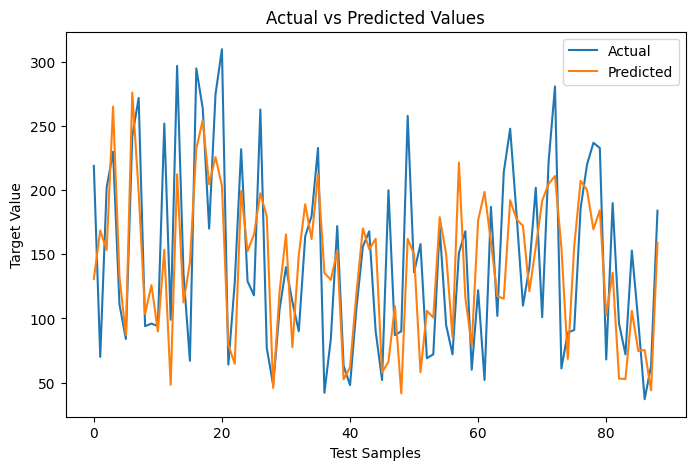

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Test Samples")
plt.ylabel("Target Value")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

### Final Model Summary

The final model uses all nine features remaining after removing `sex`.


In [36]:
print("Multiple Linear Regression")
print("\nSelected Features:")
print(selected_features)
print("\nNumber of Selected Features:", len(selected_features))
print("\nTest Set Performance:")
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))
print("\nMean 5-Fold CV R²:", round(cv_scores.mean(), 4))

Multiple Linear Regression

Selected Features:
['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Number of Selected Features: 9

Test Set Performance:
MAE : 44.2677
MSE : 2986.7329
RMSE: 54.651
R²  : 0.4363

Mean 5-Fold CV R²: 0.4785
